In [1]:
import os
import re
import glob
import pandas as pd
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pyslha
import xml.etree.ElementTree as ET
import pyslha
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

cm = plt.colormaps['RdYlBu']


In [2]:
pd.read_pickle('/home/ramos/ma5Results_axial.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
0,IM0,8.534284,8.538081,0.094503,0.004867,0.000260,dma_1000_10,10.0,1000.0
1,IM1,4.409492,4.414570,0.072209,0.004306,0.000260,dma_1000_10,10.0,1000.0
2,IM2,3.336647,3.345726,0.054157,0.003766,0.000260,dma_1000_10,10.0,1000.0
3,IM3,2.449853,2.464980,0.040794,0.003291,0.000260,dma_1000_10,10.0,1000.0
4,IM4,2.141699,2.165333,0.029762,0.002827,0.000260,dma_1000_10,10.0,1000.0
...,...,...,...,...,...,...,...,...,...
2049,EM8,1.148875,1.224121,0.000775,0.000021,0.133546,dma_500_995,995.0,500.0
2050,EM9,1.150160,1.036460,0.000387,0.000015,0.133546,dma_500_995,995.0,500.0
2051,EM10,2.043404,3.589709,0.000194,0.000010,0.133546,dma_500_995,995.0,500.0
2052,EM11,2.679273,2.945245,0.000083,0.000007,0.133546,dma_500_995,995.0,500.0


In [3]:
pd.read_pickle('/home/ramos/ma5Results_axial_add.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
0,IM0,41.562392,41.576814,0.018532,0.000012,8.470793,dma_100_10,10.0,100.0
1,IM1,26.835339,26.859584,0.011368,0.000010,8.470793,dma_100_10,10.0,100.0
2,IM2,25.132638,25.183693,0.006690,0.000008,8.470793,dma_100_10,10.0,100.0
3,IM3,21.957866,22.056093,0.004130,0.000006,8.470793,dma_100_10,10.0,100.0
4,IM4,22.766144,22.943636,0.002472,0.000005,8.470793,dma_100_10,10.0,100.0
...,...,...,...,...,...,...,...,...,...
1711,EM8,0.789179,0.842512,0.001128,0.000095,0.009061,dma_600_750,750.0,600.0
1712,EM9,0.578438,0.521256,0.000770,0.000078,0.009061,dma_600_750,750.0,600.0
1713,EM10,1.118858,2.396994,0.000358,0.000053,0.009061,dma_600_750,750.0,600.0
1714,EM11,0.808475,0.889602,0.000275,0.000047,0.009061,dma_600_750,750.0,600.0


In [4]:
df_a1 = pd.read_pickle('/home/ramos/ma5Results_axial.pcl')
df_a2 = pd.read_pickle('/home/ramos/ma5Results_axial_add.pcl')
dfs_a = [df_a1, df_a2]

df_a = pd.concat(dfs_a, ignore_index=True)
df_v = pd.read_pickle('/home/ramos/ma5Results_vector.pcl')

In [5]:
# get datapoints in common
mCols = ['mMed (GeV)', 'mchi (GeV)']
keys = list(df_a[mCols].columns.values)
i1 = df_a.set_index(keys).index
i2 = df_v.set_index(keys).index
dataAx = df_a[i1.isin(i2)]
dataVec = df_v[i2.isin(i1)]
print(len(dataAx), len(dataVec))

3406 3406


In [6]:
# choose only EM
srs = [c for c in dataAx['Signal Region'] if not 'IM' in c]
dataAx = dataAx[dataAx['Signal Region'].isin(srs)]
dataVec = dataVec[dataVec['Signal Region'].isin(srs)]

In [7]:
dataVec.T

,13,14,15,16,17,18,19,20,21,22,...,3396,3397,3398,3399,3400,3401,3402,3403,3404,3405
Signal Region,EM0,EM1,EM2,EM3,EM4,EM5,EM6,EM7,EM8,EM9,...,EM3,EM4,EM5,EM6,EM7,EM8,EM9,EM10,EM11,EM12
Sigma_95_exp (pb),21.371544,7.056581,3.498511,3.173329,2.192671,1.043132,0.870158,0.810785,0.572944,0.51147,...,3.563124,2.718543,1.380644,1.280176,1.052817,1.077207,0.843373,1.082148,1.262974,0.767828
Sigma_95_obs (pb),21.377747,7.054959,3.497781,3.204326,2.243252,1.075557,0.941311,0.946172,0.614823,0.460852,...,3.595105,2.772644,1.415299,1.359604,1.178169,1.147759,0.760001,2.104174,1.388347,0.655419
Efficiency,0.020314,0.017401,0.014111,0.009585,0.012823,0.007556,0.004838,0.00251,0.001561,0.000871,...,0.008359,0.009876,0.005581,0.003143,0.001856,0.000826,0.000528,0.000366,0.000176,0.000298
Stat,0.001111,0.00103,0.000929,0.000767,0.000886,0.000682,0.000547,0.000394,0.000311,0.000232,...,0.000126,0.000137,0.000103,0.000077,0.00006,0.00004,0.000032,0.000027,0.000018,0.000024
Sigma_theoretical (pb),0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,...,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832
SAF File,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,...,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750
mMed (GeV),10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0
mchi (GeV),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,...,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0


In [8]:
dataAx = dataAx.rename(columns={'Efficiency': 'eff_a', 'Stat': 'stat_a'})
dataVec = dataVec.rename(columns={'Efficiency': 'eff_v', 'Stat': 'stat_v'})

In [9]:
dataVec

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),eff_v,stat_v,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
13,EM0,21.371544,21.377747,0.020314,0.001111,0.001163,dmv_1000_10,10.0,1000.0
14,EM1,7.056581,7.054959,0.017401,0.001030,0.001163,dmv_1000_10,10.0,1000.0
15,EM2,3.498511,3.497781,0.014111,0.000929,0.001163,dmv_1000_10,10.0,1000.0
16,EM3,3.173329,3.204326,0.009585,0.000767,0.001163,dmv_1000_10,10.0,1000.0
17,EM4,2.192671,2.243252,0.012823,0.000886,0.001163,dmv_1000_10,10.0,1000.0
...,...,...,...,...,...,...,...,...,...
3401,EM8,1.077207,1.147759,0.000826,0.000040,0.037832,dmv_600_750,750.0,600.0
3402,EM9,0.843373,0.760001,0.000528,0.000032,0.037832,dmv_600_750,750.0,600.0
3403,EM10,1.082148,2.104174,0.000366,0.000027,0.037832,dmv_600_750,750.0,600.0
3404,EM11,1.262974,1.388347,0.000176,0.000018,0.037832,dmv_600_750,750.0,600.0


In [10]:
file_names = list(dataAx['SAF File'].unique())

In [13]:
reducedChis = []
redChis_dict = {}

for f in file_names:
    eff_a = np.array(dataAx[dataAx['SAF File'] == f]['eff_a'])
    stat_a = np.array(dataAx[dataAx['SAF File'] == f]['stat_a'])
    
    f_v = f.replace('a', 'v')
    eff_v = np.array(dataVec[dataVec['SAF File'] == f_v]['eff_v'])
    stat_v = np.array(dataVec[dataVec['SAF File'] == f_v]['stat_v'])

    diff = (eff_v - eff_a)**2
    sigmaTot = (stat_v**2 + stat_a**2)
    for s in sigmaTot:
        if s == 0:
            print(f)
    redChi = diff/sigmaTot

    dof = len(diff) - 1
    # print(chi)
    # print(sum(chi), dof)
    np.nan_to_num(redChi)
    reducedChis.append(redChi.sum()/dof)
    redChis_dict[f] = redChi.sum()/dof


dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_100
dma_1_250
dma_1_250
dma_1_250
dma_1_250
dma_1_250
dma_1_250
dma_100_10
dma_100_10
dma_100_250
dma_100_250
dma_100_250
dma_100_250
dma_100_250
dma_100_300
dma_100_300
dma_100_500
dma_200_10


/tmp/ipykernel_56057/2766005425.py:17: RuntimeWarning: divide by zero encountered in divide
  redChi = diff/sigmaTot
/tmp/ipykernel_56057/2766005425.py:17: RuntimeWarning: invalid value encountered in divide
  redChi = diff/sigmaTot


In [12]:
redChis_dict

{'dma_1000_10': np.float64(0.17433569708535146),
 'dma_1000_1000': np.float64(0.16607476926678308),
 'dma_1000_1250': np.float64(0.21625055535915694),
 'dma_1000_1500': np.float64(0.36925527955309656),
 'dma_1000_1750': np.float64(0.6656554475590708),
 'dma_1000_1995': np.float64(1.9697176601420043),
 'dma_1000_2250': np.float64(7.900833101517537),
 'dma_1000_250': np.float64(0.14402478499654395),
 'dma_1000_2500': np.float64(7.13497517308845),
 'dma_1000_2750': np.float64(3.970520007789961),
 'dma_1000_3000': np.float64(2.8128754489623815),
 'dma_1000_500': np.float64(0.17040052117594873),
 'dma_1000_750': np.float64(0.10093343660267579),
 'dma_1200_10': np.float64(0.033621569119043807),
 'dma_1200_1000': np.float64(0.07103498770540341),
 'dma_1200_1250': np.float64(0.17398920066112067),
 'dma_1200_1500': np.float64(0.08476006062638715),
 'dma_1200_1750': np.float64(0.12059427903418161),
 'dma_1200_2000': np.float64(0.10432509630199738),
 'dma_1200_2250': np.float64(0.2542597774909947

In [102]:
dataAx

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),eff_a,stat_a,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
13,EM0,-1.000000,-1.000000,0.022294,0.002456,0.000260,dma_1000_10,10.0,1000.0
14,EM1,6.802076,6.800512,0.018052,0.002215,0.000260,dma_1000_10,10.0,1000.0
15,EM2,3.694295,3.693525,0.013363,0.001910,0.000260,dma_1000_10,10.0,1000.0
16,EM3,2.757323,2.784262,0.011032,0.001738,0.000260,dma_1000_10,10.0,1000.0
17,EM4,2.331156,2.381418,0.012089,0.001818,0.000260,dma_1000_10,10.0,1000.0
...,...,...,...,...,...,...,...,...,...
3765,EM8,0.789179,0.842512,0.001128,0.000095,0.009061,dma_600_750,750.0,600.0
3766,EM9,0.578438,0.521256,0.000770,0.000078,0.009061,dma_600_750,750.0,600.0
3767,EM10,1.118858,2.396994,0.000358,0.000053,0.009061,dma_600_750,750.0,600.0
3768,EM11,0.808475,0.889602,0.000275,0.000047,0.009061,dma_600_750,750.0,600.0


In [101]:
int(file_names[0].split('_')[1])

1000

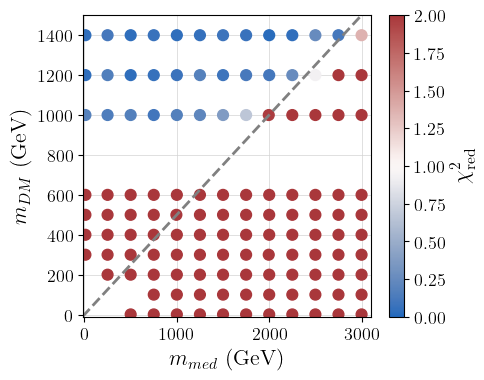

In [106]:
mmed = []
mdm = []
for f in file_names:
    dm = int(f.split('_')[1])
    med = int(f.split('_')[2])

    mmed.append(med)
    mdm.append(dm)

plt.scatter(x=mmed, y=mdm, c=reducedChis, vmin=0., vmax=2.,
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm red}$')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{DM}$ (GeV)')
plt.ylim(-10,1500)

plt.tight_layout()

plt.show()

In [15]:
# merge dfs
dataComb = pd.merge(dataAx, dataVec, on=['mchi (GeV)', 'mMed (GeV)', 'Signal Region'], how='inner')

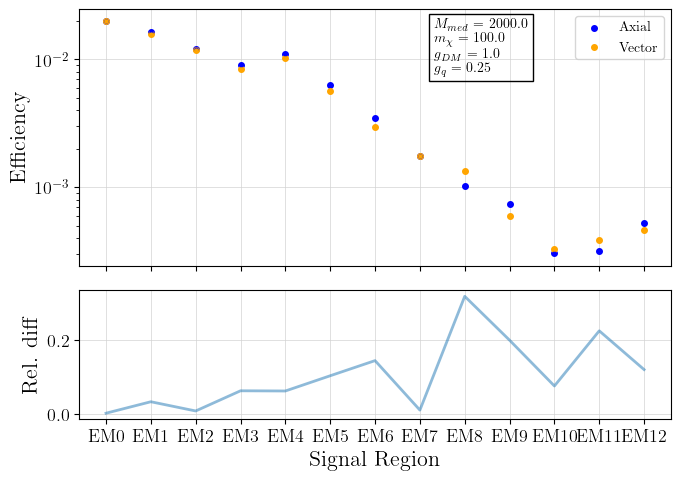

In [16]:
# plot eff diff
mxd = 100.
mmed = 2000.
mFilter = (dataComb['mchi (GeV)'] == mxd) & (dataComb['mMed (GeV)'] == mmed)
x = dataComb[mFilter]['Signal Region']
y1 = dataComb[mFilter]['eff_a']
y1_err = dataComb[mFilter]['stat_a']
y2 = dataComb[mFilter]['eff_v']
y2_err = dataComb[mFilter]['stat_v']

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [17]:
y1

910    0.020041
911    0.016391
912    0.012059
913    0.009007
914    0.010997
915    0.006261
916    0.003466
917    0.001745
918    0.001013
919    0.000745
920    0.000305
921    0.000317
922    0.000525
Name: eff_a, dtype: float64

In [18]:
y1_err

910    0.000062
911    0.000056
912    0.000048
913    0.000042
914    0.000046
915    0.000035
916    0.000026
917    0.000018
918    0.000014
919    0.000012
920    0.000008
921    0.000008
922    0.000010
Name: stat_a, dtype: float64